# PCA in Dimensional Reduction 

In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# from sklearn.tree import DecisionTreeClassifier, plot_tree
# from sklearn.metrics import classification_report , confusion_matrix, accuracy_score

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [7]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()   # ← CALL the function

df = pd.DataFrame(
    data=wine.data,
    columns=wine.feature_names
)

df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


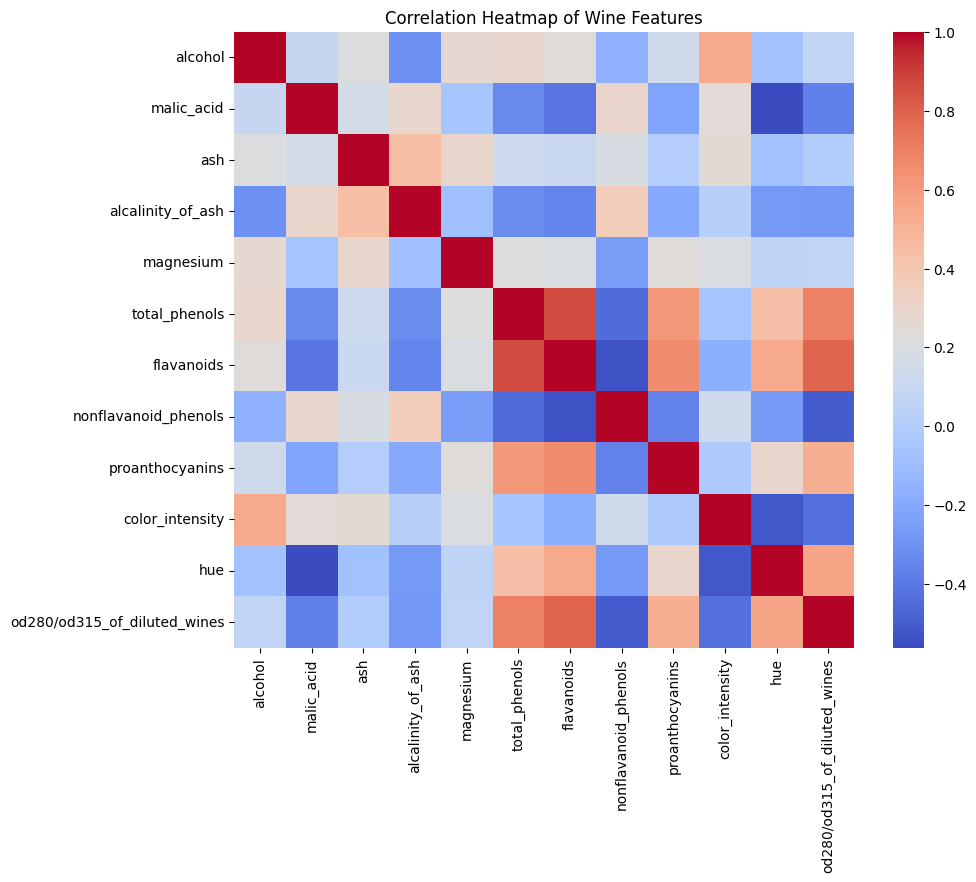

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.iloc[:,:-1].corr(), cmap="coolwarm", annot= False) #given data kop correlation nikalney ho 
plt.title("Correlation Heatmap of Wine Features")
plt.show()

In [46]:
X= df.drop(columns=["target"])
y= df["target"]

scaler = StandardScaler()
X_scaled= scaler.fit_transform(X)

In [47]:
# fit pca 

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [48]:
# explained variance 
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio :", explained_variance)

Explained Variance Ratio : [0.35514167 0.21563466 0.10352626 0.06633354 0.06150214 0.04803399
 0.03940871 0.02498777 0.02115903 0.01857949 0.01621374 0.01209941
 0.01060183 0.00677776]


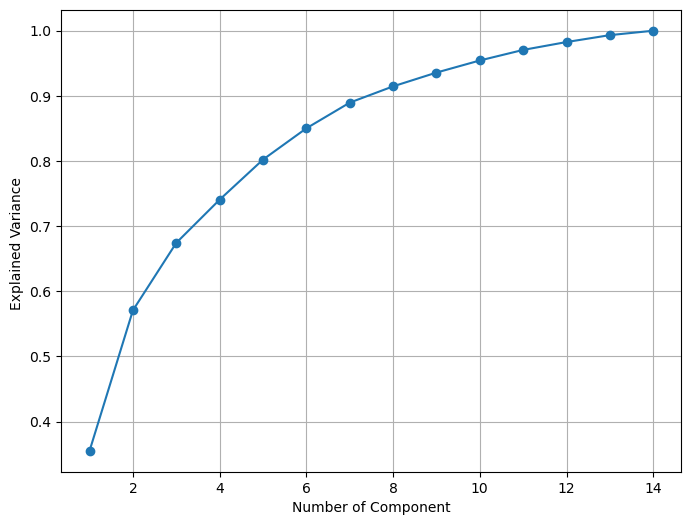

In [49]:
# screen plot 
plt.figure(figsize=(8,6))
plt.plot(range(1, len(explained_variance)+1), np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Component')
plt.ylabel('Explained Variance ')
plt.grid(True)
plt.show()

In [50]:
X= df.drop(columns=["target"])
y= df["target"]

scaler = StandardScaler()
X_scaled= scaler.fit_transform(X)

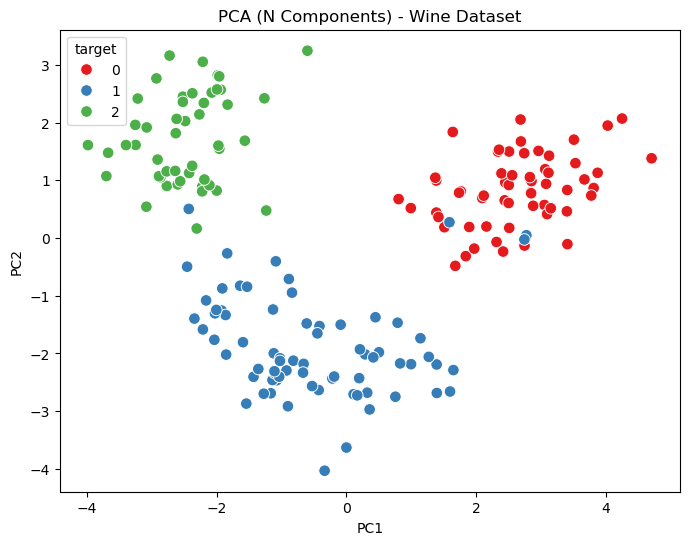

In [51]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca_2d[:,0], y=X_pca_2d[:,1], hue=y, palette="Set1", s=70)
plt.title("PCA (N Components) - Wine Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

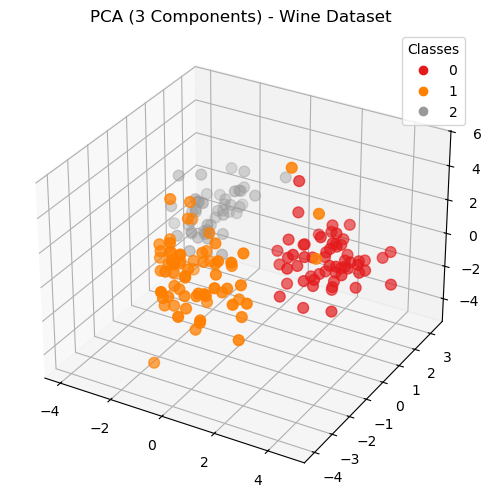

In [52]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2], c=y, cmap='Set1', s=60)
plt.title("PCA (3 Components) - Wine Dataset")
plt.legend(*sc.legend_elements(), title="Classes")
plt.show()

#  K-means 


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


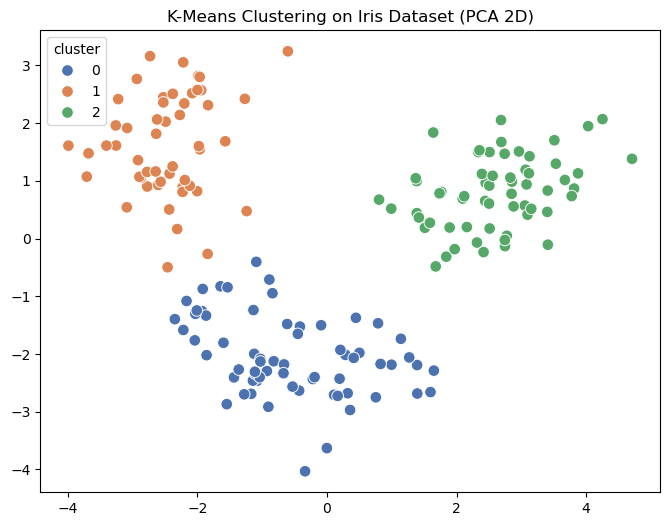

In [53]:
# Using PCA for visualization (reduce to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Try clustering into 3 groups (since we know Iris has 3 species)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add clusters to dataframe
df['cluster'] = clusters

# Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster'], palette="deep", s=70)
plt.title("K-Means Clustering on Iris Dataset (PCA 2D)")
plt.show()

# Compare true species vs cluster
#pd.crosstab(df['cluster'], df['species'])
